In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (18, 6)

class KeyGuardSiamese(nn.Module):
    def __init__(self):
        super(KeyGuardSiamese, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 16, 3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, 3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(5)
        )
        self.fc = nn.Sequential(
            nn.Linear(160, 64),
            nn.ReLU(),
            nn.Linear(64, 16)
        )

    def forward_once(self, x):
        x = self.cnn(x)
        x = x.view(x.size()[0], -1)
        return self.fc(x)

    def forward(self, input1, input2):
        return self.forward_once(input1), self.forward_once(input2)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
modelo = KeyGuardSiamese().to(DEVICE)

modelo.load_state_dict(torch.load('../data/keyguard_siamese_weights.pth', map_location=DEVICE))

modelo.eval()

tensor_X_test = torch.load('../data/tensor_X_test.pt')
tensor_y_test = torch.load('../data/tensor_y_test.pt')
test_loader = DataLoader(TensorDataset(tensor_X_test, tensor_y_test), batch_size=128, shuffle=False)

distancias_euclidianas = []
rotulos_reais = []

print("Calculando matriz de distâncias no lote de teste...")
with torch.no_grad():
    for data in test_loader:
        X_batch, y_batch = data
        X_batch = X_batch.to(DEVICE)

        input1 = X_batch[:, 0, :].unsqueeze(1)
        input2 = X_batch[:, 1, :].unsqueeze(1)

        out1, out2 = modelo(input1, input2)

        dists = F.pairwise_distance(out1, out2).cpu().numpy()

        distancias_euclidianas.extend(dists)
        rotulos_reais.extend(y_batch.numpy())

distancias_euclidianas = np.array(distancias_euclidianas)
rotulos_reais = np.array(rotulos_reais)
print("Inferência concluída com sucesso.")

Calculando matriz de distâncias no lote de teste...
Inferência concluída com sucesso.


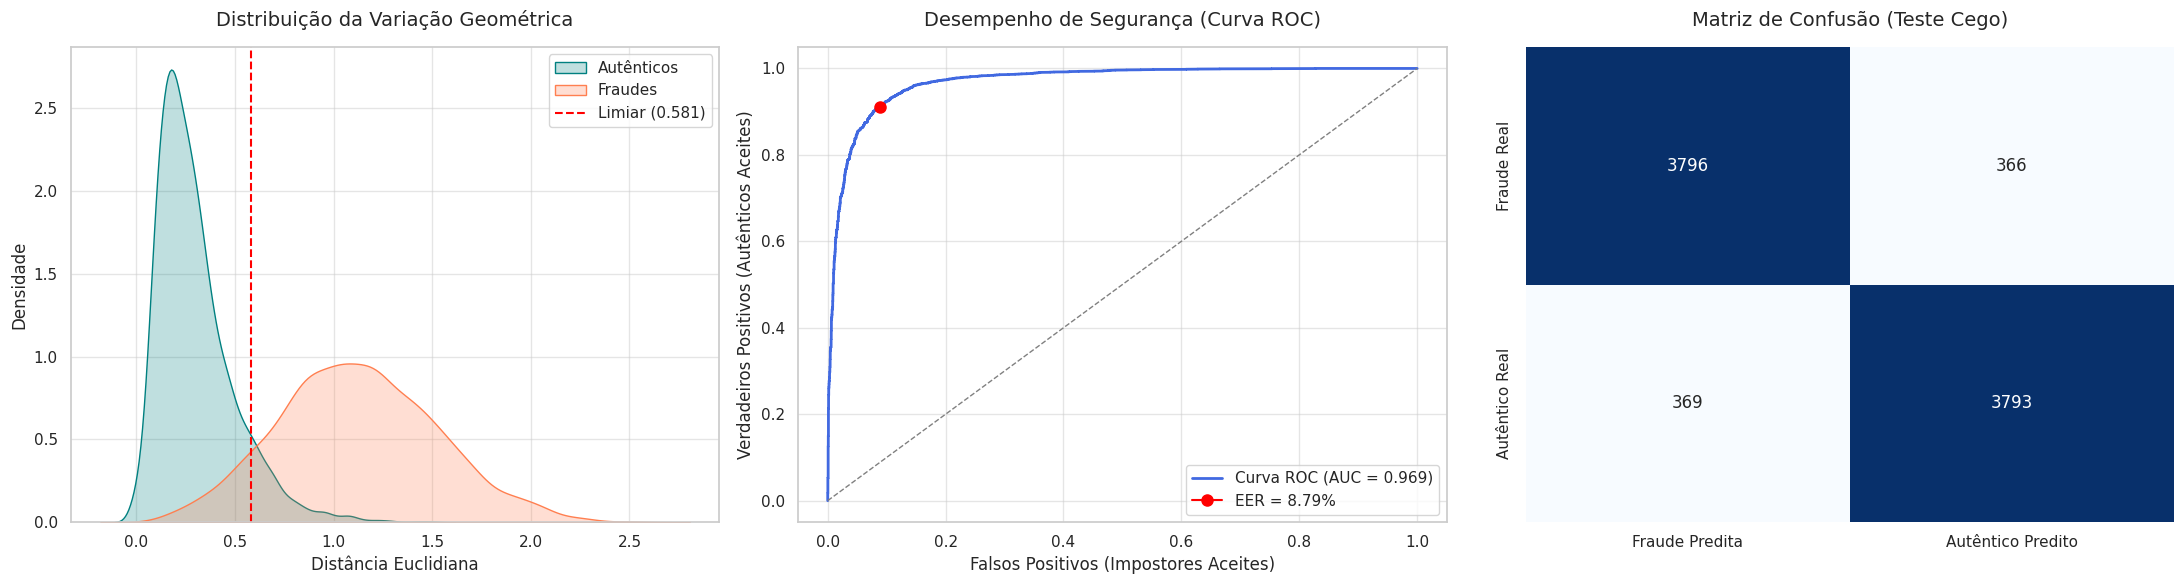


=== VEREDICTO FINAL DO MODELO ===
Taxa de Erro de Equivalência (EER): 8.79%
Área Sob a Curva (AUC): 0.9690
----------------------------------------
LIMIAR DE DECISÃO OPERACIONAL: 0.5807
-> Distâncias MENORES que o limiar: O sistema ACEITA o login.
-> Distâncias MAIORES que o limiar: O sistema BLOQUEIA / Pede MFA.


In [2]:
fpr, tpr, thresholds = roc_curve(rotulos_reais, -distancias_euclidianas)
roc_auc = auc(fpr, tpr)

fnr = 1 - tpr
eer_threshold_index = np.nanargmin(np.absolute((fnr - fpr)))
eer = fpr[eer_threshold_index]

limiar_ideal = -thresholds[eer_threshold_index]

previsoes = (distancias_euclidianas <= limiar_ideal).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

dists_autenticos = distancias_euclidianas[rotulos_reais == 1]
dists_fraudes = distancias_euclidianas[rotulos_reais == 0]

sns.kdeplot(dists_autenticos, fill=True, color='teal', label='Autênticos', ax=axes[0])
sns.kdeplot(dists_fraudes, fill=True, color='coral', label='Fraudes', ax=axes[0])
axes[0].axvline(x=limiar_ideal, color='red', linestyle='--', label=f'Limiar ({limiar_ideal:.3f})')
axes[0].set_title('Distribuição da Variação Geométrica', fontsize=14, pad=15)
axes[0].set_xlabel('Distância Euclidiana')
axes[0].set_ylabel('Densidade')
axes[0].legend()

axes[1].plot(fpr, tpr, color='royalblue', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1].plot(fpr[eer_threshold_index], tpr[eer_threshold_index], marker='o', markersize=8, color="red", label=f'EER = {eer*100:.2f}%')
axes[1].set_title('Desempenho de Segurança (Curva ROC)', fontsize=14, pad=15)
axes[1].set_xlabel('Falsos Positivos (Impostores Aceites)')
axes[1].set_ylabel('Verdadeiros Positivos (Autênticos Aceites)')
axes[1].legend(loc="lower right")

cm = confusion_matrix(rotulos_reais, previsoes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[2],
            xticklabels=['Fraude Predita', 'Autêntico Predito'],
            yticklabels=['Fraude Real', 'Autêntico Real'])
axes[2].set_title('Matriz de Confusão (Teste Cego)', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

print("\n=== VEREDICTO FINAL DO MODELO ===")
print(f"Taxa de Erro de Equivalência (EER): {eer*100:.2f}%")
print(f"Área Sob a Curva (AUC): {roc_auc:.4f}")
print("-" * 40)
print(f"LIMIAR DE DECISÃO OPERACIONAL: {limiar_ideal:.4f}")
print("-> Distâncias MENORES que o limiar: O sistema ACEITA o login.")
print("-> Distâncias MAIORES que o limiar: O sistema BLOQUEIA / Pede MFA.")